# Suicide Rates & Socioeconomic Analysis — Exploratory Data Analysis

This analysis uses country-level age-standardized suicide rate data from 1991–2022.

The objective is to understand:
- data quality and coverage
- trends in suicide rates
- regional differences
- gender disparities
- country-level variation
- relationships between suicide rates and socioeconomic indicators

The analysis focuses on descriptive and exploratory analysis. Observed relationships are interpreted as associations rather than causal effects.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

In [30]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / ".git").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from config.paths import DATA_DIR

DATA_PATH = DATA_DIR / "age_std_suicide_rates_1990-2022_transformed.csv"

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 4,836
Columns: 16


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4836 entries, 0 to 4835
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   RegionCode                    4836 non-null   str    
 1   RegionName                    4836 non-null   str    
 2   CountryCode                   4836 non-null   str    
 3   CountryName                   4836 non-null   str    
 4   Year                          4836 non-null   int64  
 5   Sex                           4836 non-null   str    
 6   SuicideCount                  4836 non-null   int64  
 7   CauseSpecificDeathPercentage  4836 non-null   float64
 8   StdDeathRate                  4836 non-null   float64
 9   DeathRatePer100K              4836 non-null   float64
 10  Population                    4836 non-null   float64
 11  GDP                           4836 non-null   float64
 12  GDPPerCapita                  4836 non-null   float64
 13  GNI           

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,4836.0,2.006832e+03,8.277699e+00,1.991000e+03,2.000000e+03,2.007000e+03,2.014000e+03,2.022000e+03
SuicideCount,4836.0,1.427866e+03,4.166831e+03,0.000000e+00,4.200000e+01,2.715000e+02,9.242500e+02,5.146400e+04
CauseSpecificDeathPercentage,4836.0,1.259767e+00,1.116199e+00,0.000000e+00,4.422241e-01,8.928810e-01,1.888102e+00,7.585340e+00
StdDeathRate,4836.0,9.448838e+00,1.042385e+01,0.000000e+00,2.434311e+00,5.969386e+00,1.280476e+01,7.652862e+01
DeathRatePer100K,4836.0,1.060484e+01,1.153668e+01,0.000000e+00,2.664324e+00,6.798716e+00,1.442085e+01,8.143961e+01
Population,4836.0,2.537261e+07,4.671936e+07,7.382100e+04,2.612205e+06,6.979182e+06,2.650941e+07,3.320316e+08
GDP,4836.0,5.388048e+11,1.764327e+12,3.007579e+08,1.294873e+10,6.768110e+10,3.240000e+11,2.330000e+13
GDPPerCapita,4836.0,1.883566e+04,2.015117e+04,1.570635e+02,4.115155e+03,1.090763e+04,2.736188e+04,1.337118e+05
GNI,4836.0,5.382076e+11,1.781335e+12,2.933784e+08,1.250383e+10,6.297916e+10,3.200000e+11,2.370000e+13
GNIPerCapita,4836.0,2.334659e+04,1.937368e+04,1.080000e+03,8.940000e+03,1.793000e+04,3.162000e+04,1.526300e+05


In [33]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [34]:
duplicate_grain = df.duplicated(subset=["CountryCode", "Year", "Sex"]).sum()

print("Duplicate Country-Year-Gender records:", duplicate_grain)

Duplicate Country-Year-Gender records: 0


In [35]:
coverage_by_year = (df.groupby("Year").agg(countries=("CountryCode", "nunique"),records=("CountryCode", "size")).reset_index())
coverage_by_year.head()

,Year,countries,records
0,1991,43,86
1,1992,46,92
2,1993,51,102
3,1994,55,110
4,1995,63,126


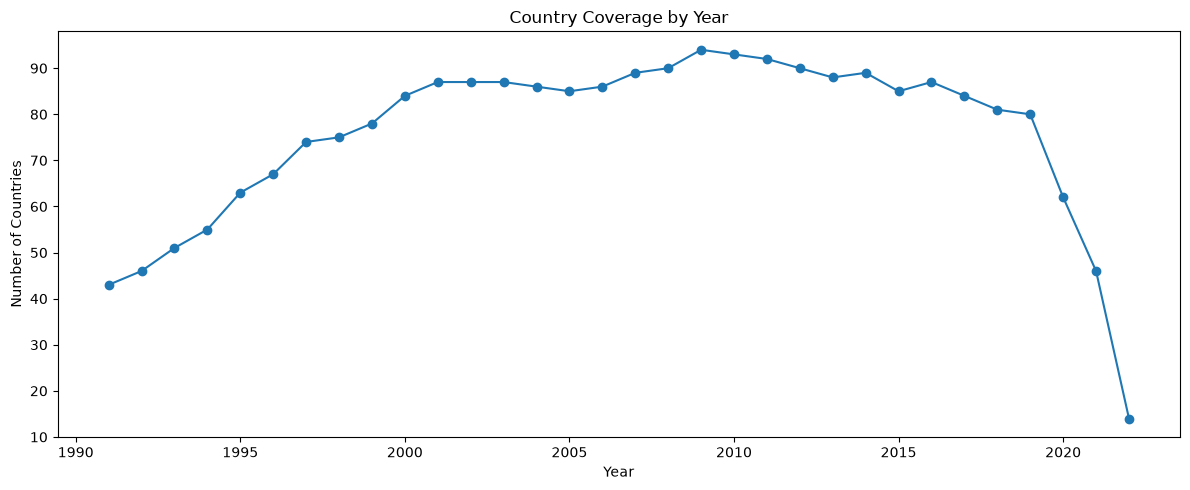

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(coverage_by_year["Year"],coverage_by_year["countries"],marker="o")

plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.title("Country Coverage by Year")

plt.tight_layout()
plt.show()

In [37]:
df["DeathRatePer100K"].describe()

count    4836.000000
mean       10.604845
std        11.536678
min         0.000000
25%         2.664324
50%         6.798716
75%        14.420853
max        81.439608
Name: DeathRatePer100K, dtype: float64

In [38]:
df["DeathRatePer100K"].describe()

count    4836.000000
mean       10.604845
std        11.536678
min         0.000000
25%         2.664324
50%         6.798716
75%        14.420853
max        81.439608
Name: DeathRatePer100K, dtype: float64

In [39]:
yearly_rate = (df.groupby("Year").agg(mean_rate=("DeathRatePer100K", "mean"),median_rate=("DeathRatePer100K", "median"),
          countries=("CountryCode", "nunique")).reset_index())

yearly_rate.head()

,Year,mean_rate,median_rate,countries
0,1991,10.484087,8.607343,43
1,1992,10.729246,8.572300,46
2,1993,12.157911,9.049406,51
3,1994,12.022170,8.055738,55
4,1995,12.126691,8.973106,63


In [40]:
df[["DeathRatePer100K", "SuicideCount", "Population", "GDPPerCapita", "GNIPerCapita", "InflationRate"]].describe().T

,count,mean,std,min,25%,50%,75%,max
DeathRatePer100K,4836.0,1.060484e+01,1.153668e+01,0.00000,2.664324e+00,6.798716e+00,1.442085e+01,8.143961e+01
SuicideCount,4836.0,1.427866e+03,4.166831e+03,0.00000,4.200000e+01,2.715000e+02,9.242500e+02,5.146400e+04
Population,4836.0,2.537261e+07,4.671936e+07,73821.00000,2.612205e+06,6.979182e+06,2.650941e+07,3.320316e+08
GDPPerCapita,4836.0,1.883566e+04,2.015117e+04,157.06355,4.115155e+03,1.090763e+04,2.736188e+04,1.337118e+05
GNIPerCapita,4836.0,2.334659e+04,1.937368e+04,1080.00000,8.940000e+03,1.793000e+04,3.162000e+04,1.526300e+05
InflationRate,4836.0,1.749416e+01,1.583625e+02,-8.52517,1.467967e+00,2.934457e+00,6.218094e+00,4.734914e+03


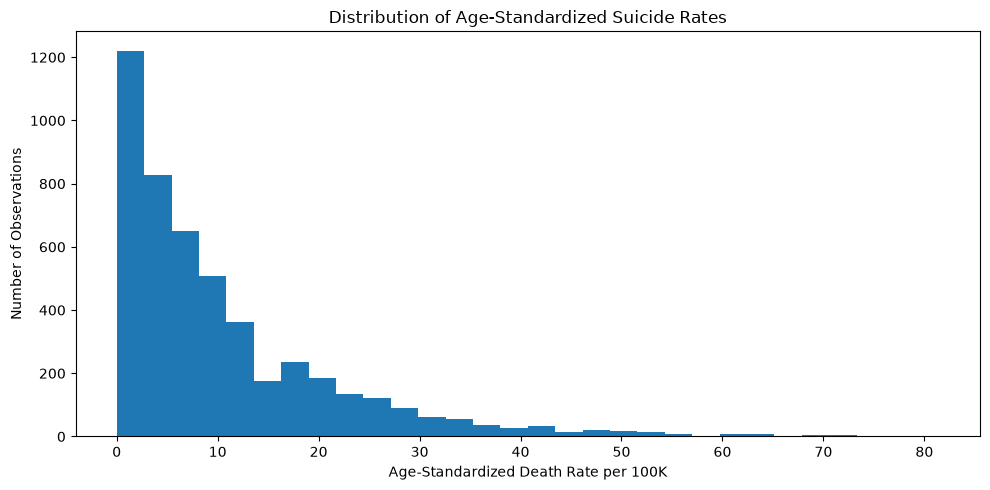

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["DeathRatePer100K"],bins=30)

plt.xlabel("Age-Standardized Death Rate per 100K")
plt.ylabel("Number of Observations")
plt.title("Distribution of Age-Standardized Suicide Rates")

plt.tight_layout()
plt.show()

In [42]:
rate_stats = df["DeathRatePer100K"].agg(["count", "mean", "median", "min", "max"])
rate_stats

count     4836.000000
mean        10.604845
median       6.798716
min          0.000000
max         81.439608
Name: DeathRatePer100K, dtype: float64

In [43]:
print(f"Skewness: {df['DeathRatePer100K'].skew():.2f}")

Skewness: 2.07


In [44]:
gender_summary = df.groupby("Sex")["DeathRatePer100K"].agg(observations="count", mean="mean", median="median", min="min", max="max").round(2)
gender_summary

,observations,mean,median,min,max
Sex,,,,,
Female,2418,4.69,4.00,0.0,22.11
Male,2418,16.52,13.63,0.0,81.44


In [45]:
gender_mean = df.groupby("Sex")["DeathRatePer100K"].mean()
male_female_ratio = gender_mean["Male"] / gender_mean["Female"]
print(f"Mean male-to-female rate ratio: {male_female_ratio:.2f}")

Mean male-to-female rate ratio: 3.52


In [46]:
regional_summary = df.groupby("RegionName").agg(observations=("CountryCode", "size"), countries=("CountryCode", "nunique"), 
mean_rate=("DeathRatePer100K", "mean"), median_rate=("DeathRatePer100K", "median")).sort_values("mean_rate", ascending=False).round(2)
regional_summary

,observations,countries,mean_rate,median_rate
RegionName,,,,
Europe,2020,38,15.32,10.89
Oceania,136,3,11.01,6.41
Asia,1076,30,7.88,3.71
Central and South America,866,17,7.41,5.07
North America and the Caribbean,548,11,5.44,2.74
Africa,190,5,5.02,1.73


In [47]:
gender_country = df.pivot_table(index=["CountryCode", "CountryName", "Year"], columns="Sex", values="DeathRatePer100K").reset_index()
gender_country["male_female_gap"] = gender_country["Male"] - gender_country["Female"]
gender_country["male_female_ratio"] = gender_country["Male"] / gender_country["Female"].replace(0, np.nan)
gender_gap_summary = gender_country[["male_female_gap", "male_female_ratio"]].describe().round(2)
gender_gap_summary

Sex,male_female_gap,male_female_ratio
count,2418.00,2255.00
mean,11.82,3.80
std,10.49,1.89
min,-2.06,0.00
25%,4.56,2.72
50%,9.25,3.48
75%,16.46,4.52
max,68.20,25.31


In [48]:
economic_columns = ["DeathRatePer100K","GDPPerCapita","GNIPerCapita","InflationRate"]
df[economic_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
DeathRatePer100K,4836.0,10.604845,11.536678,0.00000,2.664324,6.798716,14.420853,81.439608
GDPPerCapita,4836.0,18835.664581,20151.173136,157.06355,4115.154549,10907.632560,27361.875110,133711.794400
GNIPerCapita,4836.0,23346.588089,19373.683535,1080.00000,8940.000000,17930.000000,31620.000000,152630.000000
InflationRate,4836.0,17.494164,158.362479,-8.52517,1.467967,2.934457,6.218094,4734.914347


In [49]:
df[economic_columns].corr(method="spearman").round(2)

,DeathRatePer100K,GDPPerCapita,GNIPerCapita,InflationRate
DeathRatePer100K,1.00,0.20,0.17,-0.00
GDPPerCapita,0.20,1.00,0.95,-0.53
GNIPerCapita,0.17,0.95,1.00,-0.53
InflationRate,-0.00,-0.53,-0.53,1.00


In [50]:
df["LogGDPPerCapita"] = np.log1p(df["GDPPerCapita"])
df["LogGNIPerCapita"] = np.log1p(df["GNIPerCapita"])

In [51]:
df[["DeathRatePer100K","LogGDPPerCapita","LogGNIPerCapita","InflationRate"]].corr(method="spearman").round(2)

,DeathRatePer100K,LogGDPPerCapita,LogGNIPerCapita,InflationRate
DeathRatePer100K,1.00,0.20,0.17,-0.00
LogGDPPerCapita,0.20,1.00,0.95,-0.53
LogGNIPerCapita,0.17,0.95,1.00,-0.53
InflationRate,-0.00,-0.53,-0.53,1.00


In [52]:
high_rate = df.nlargest(10, "DeathRatePer100K")
high_rate[["CountryName","Year","Sex","DeathRatePer100K"]]

,CountryName,Year,Sex,DeathRatePer100K
2496,Lithuania,2002,Male,81.439608
2492,Lithuania,2000,Male,80.421784
2486,Lithuania,1997,Male,80.297936
2490,Lithuania,1999,Male,77.956014
2494,Lithuania,2001,Male,77.485357
2488,Lithuania,1998,Male,77.255426
2498,Lithuania,2003,Male,75.287682
3854,Russian Federation,1994,Male,74.623143
3856,Russian Federation,1995,Male,72.895554
3868,Russian Federation,2001,Male,71.741834


In [53]:
df.nlargest(50, "DeathRatePer100K")["CountryName"].value_counts()

CountryName
Lithuania             19
Russian Federation    14
Belarus               10
Latvia                 4
Hungary                2
Ukraine                1
Name: count, dtype: int64

In [54]:
df[economic_columns].corr(method="spearman").round(2)

,DeathRatePer100K,GDPPerCapita,GNIPerCapita,InflationRate
DeathRatePer100K,1.00,0.20,0.17,-0.00
GDPPerCapita,0.20,1.00,0.95,-0.53
GNIPerCapita,0.17,0.95,1.00,-0.53
InflationRate,-0.00,-0.53,-0.53,1.00


## Key Findings

- Age-standardized suicide rates show substantial variation across country-year-sex observations and follow a positively skewed distribution.
- Male suicide rates are considerably higher than female rates in the dataset.
- Suicide rates vary substantially across regions and individual country-year-sex observations.
- GDP per capita and GNI per capita show weak positive associations with suicide rates (Spearman correlations of 0.20 and 0.17 respectively).
- Inflation shows essentially no monotonic association with suicide rates in this dataset.
- GDP per capita and GNI per capita are highly correlated (0.95), indicating that they capture closely related socioeconomic information.
- High-rate observations were investigated rather than automatically removed, as extreme values may represent genuine country-level patterns.
- These relationships are exploratory associations and should not be interpreted as causal effects.